# EPD Calibration Reliability System
## 01 — Problem, Data, and Baselines

### Goal

Given the ADC response of one EPD tile during one day of data taking,
determine whether its calibration can be trusted automatically or should
be sent for expert review.

Secondary task:
Estimate the accepted first-MIP MPV for reliable tile-day samples.

### Existing workflow

PicoDst
→ per-tile ADC histograms
→ automatic multi-MIP Landau-convolution fit
→ daily first-MIP MPV + fit uncertainty
→ cross-day consistency checks
→ manual review/refit of suspicious tiles
→ candidate calibration constants

The existing deterministic calibration is the baseline, not something
the ML system should automatically replace.

### ML product question

Can a model reduce expert review workload while maintaining or improving
the reliability of accepted calibrations?

A false accept is more costly than an unnecessary manual review.

## Dataset Contract

### Prediction unit

One row = one `(day, EW, PP, TT)` tile-day.

### Raw input

- 4096-bin ADC histogram for that tile and day

### Metadata

- day
- EW
- PP
- TT

### Existing calibration outputs

- automatic first-MIP MPV
- MPV fit uncertainty
- fit status
- deviation from nominal calibration
- cross-day average MPV
- cross-day deviation from average
- cross-day consistency statistic, where available

### Human-review information

- whether the tile was manually refit
- manually accepted MPV, if available
- whether the manual MPV materially differs from the automatic fit

## Label Policy — Version 0

The current workflow does not provide a complete ground-truth label for
every tile-day.

Therefore labels are divided into confidence levels.

### Positive: needs_review = 1

High-confidence examples may include:

1. automatic fit failure;
2. tile-day manually selected for refitting;
3. manual refit produces a materially different accepted MPV.

### Negative: needs_review = 0

High-confidence examples should satisfy:

1. automatic fit succeeds;
2. calibration is stable across neighboring days;
3. no manual correction is recorded;
4. no obvious QA anomaly is present.

### Unknown

Ambiguous tile-days are excluded from the first supervised dataset
rather than forcing a noisy label.

This makes the first dataset a high-confidence subset rather than the
entire detector history.

In [12]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nMatched files:")
print(list(Path(".").glob("NmipConstantsDay[0-9][0-9][0-9].txt")))

Current working directory:
/content

Matched files:
[]


In [13]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
ifrom pathlib import Path

print("Current working directory:", Path.cwd())

print("\nMyDrive top-level folders:")
for p in Path("/content/drive/MyDrive").iterdir():
    if p.is_dir():
        print(p.name)

Current working directory: /content

MyDrive top-level folders:
DOC
CMS
BNL
FNAL
QM2019
Colab Notebooks
Picture
Log2020
Audio
video
machine learning
eic
Music
Calendar
03 (March)
认识觉醒
NNPSS 2022
EPD Calibration
code
EPDInstallationPhotos


In [15]:
'''
from pathlib import Path

matches = list(
    Path("/content/drive/MyDrive/Calendar").rglob(
        "daily_observations_primary.csv"
    )
)

for p in matches:
    print(p)
'''

'\nfrom pathlib import Path\n\nmatches = list(\n    Path("/content/drive/MyDrive/Calendar").rglob(\n        "daily_observations_primary.csv"\n    )\n)\n\nfor p in matches:\n    print(p)\n'

In [16]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(
    "/content/drive/MyDrive/Calendar/2026/09 Sep/"
    "EPD_Calibration_ML/data/derived"
)

daily = pd.read_csv(DATA_DIR / "daily_observations_primary.csv")
references = pd.read_csv(DATA_DIR / "period_references.csv")
manual = pd.read_csv(DATA_DIR / "manual_refits.csv")

print("daily:", daily.shape)
print("references:", references.shape)
print("manual:", manual.shape)

daily: (28272, 11)
references: (2232, 12)
manual: (106, 10)


In [17]:
available_days = sorted(daily["day"].unique())

expected_days = list(range(167, 214))

missing_days = [
    day for day in expected_days
    if day not in available_days
]

print("Available days:")
print(available_days)

print("\nNumber of available days:")
print(len(available_days))

print("\nDays without complete daily observations:")
print(missing_days)

Available days:
[np.int64(167), np.int64(168), np.int64(169), np.int64(170), np.int64(171), np.int64(172), np.int64(173), np.int64(174), np.int64(175), np.int64(176), np.int64(177), np.int64(178), np.int64(179), np.int64(180), np.int64(181), np.int64(182), np.int64(190), np.int64(191), np.int64(192), np.int64(193), np.int64(194), np.int64(195), np.int64(196), np.int64(197), np.int64(198), np.int64(199), np.int64(200), np.int64(201), np.int64(202), np.int64(203), np.int64(204), np.int64(205), np.int64(206), np.int64(207), np.int64(208), np.int64(211), np.int64(212), np.int64(213)]

Number of available days:
38

Days without complete daily observations:
[183, 184, 185, 186, 187, 188, 189, 209, 210]


                mpv     mpv_error
count  2.827200e+04  2.827200e+04
mean   3.051711e+17  1.401326e+17
std    5.107723e+19  2.356228e+19
min   -2.752833e+11  2.740000e-04
25%    1.317288e+02  3.229357e-01
50%    1.343456e+02  4.684925e-01
75%    1.369662e+02  6.489333e-01
max    8.588179e+21  3.961828e+21


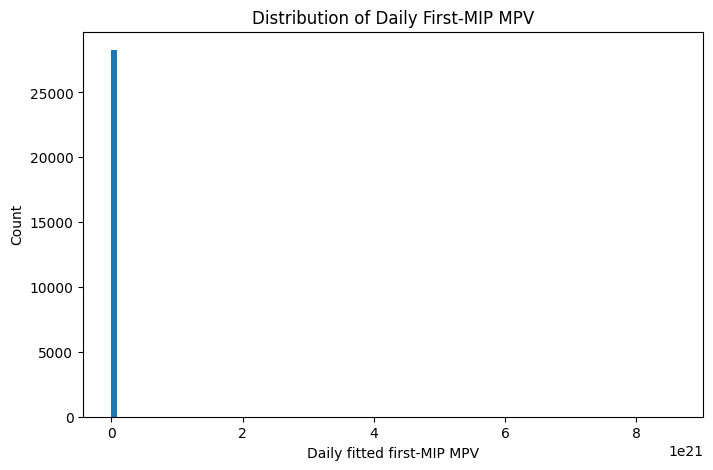

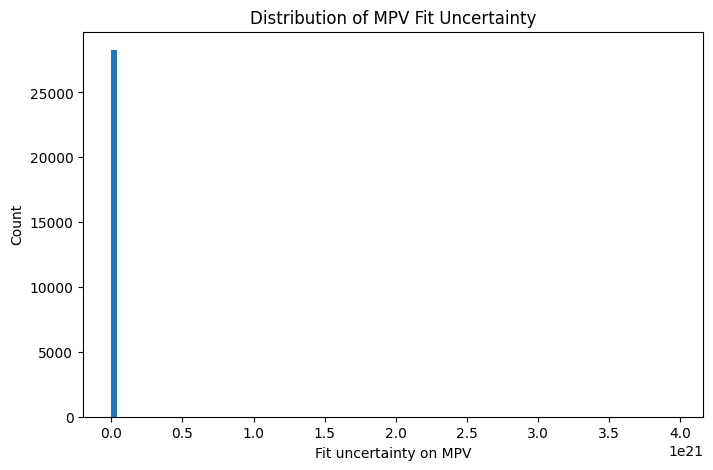

In [18]:
import matplotlib.pyplot as plt

print(daily[["mpv", "mpv_error"]].describe())

plt.figure(figsize=(8, 5))
plt.hist(daily["mpv"], bins=100)
plt.xlabel("Daily fitted first-MIP MPV")
plt.ylabel("Count")
plt.title("Distribution of Daily First-MIP MPV")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(daily["mpv_error"], bins=100)
plt.xlabel("Fit uncertainty on MPV")
plt.ylabel("Count")
plt.title("Distribution of MPV Fit Uncertainty")
plt.show()

In [19]:
cols = [
    "day", "ew", "pp", "tt",
    "mpv", "mpv_error",
    "auto_flag", "source"
]

print("=== Lowest MPV ===")
display(
    daily.sort_values("mpv")[cols].head(20)
)

print("\n=== Highest MPV ===")
display(
    daily.sort_values("mpv", ascending=False)[cols].head(20)
)

print("\n=== Largest MPV errors ===")
display(
    daily.sort_values("mpv_error", ascending=False)[cols].head(20)
)

=== Lowest MPV ===


,day,ew,pp,tt,mpv,mpv_error,auto_flag,source
8148,193,1,11,27,-2.752833e+11,6.119768e+10,different_from_nominal,ding
20011,211,1,10,17,-5.337366e+01,1.787132e+05,fit_failed,ding
5208,190,0,1,1,3.002668e+01,4.687940e-01,different_from_nominal,ding
8180,193,1,12,28,4.383496e+01,1.112447e+05,fit_failed,ding
8017,193,1,7,20,7.576037e+01,4.081927e+00,fit_failed,ding
20012,211,1,10,18,7.659973e+01,1.221318e+00,fit_failed,ding
20029,211,1,11,4,8.834084e+01,1.167217e+00,different_from_nominal,ding
19968,211,1,9,5,9.091612e+01,1.056030e+00,different_from_nominal,ding
19967,211,1,9,4,9.097380e+01,1.124020e+00,different_from_nominal,ding
20030,211,1,11,5,9.109990e+01,9.830420e-01,different_from_nominal,ding



=== Highest MPV ===


,day,ew,pp,tt,mpv,mpv_error,auto_flag,source
8147,193,1,11,26,8.588179e+21,1.414214e+00,different_from_nominal,ding
20045,211,1,11,20,3.961828e+19,1.414214e+00,different_from_nominal,ding
20758,212,1,10,20,1.063701e+07,1.414214e+00,different_from_nominal,ding
8153,193,1,12,1,6.432941e+05,1.414214e+00,different_from_nominal,ding
8021,193,1,7,24,1.142534e+05,1.414214e+00,different_from_nominal,ding
8149,193,1,11,28,6.133268e+04,1.414214e+00,different_from_nominal,ding
8045,193,1,8,17,6.517798e+03,4.427150e+02,different_from_nominal,ding
19987,211,1,9,24,4.197635e+03,3.284400e+00,fit_failed,ding
8052,193,1,8,24,4.183641e+03,6.797250e-01,different_from_nominal,ding
8154,193,1,12,2,4.155458e+03,4.305605e+00,fit_failed,ding



=== Largest MPV errors ===


,day,ew,pp,tt,mpv,mpv_error,auto_flag,source
20044,211,1,11,19,1.796075e+03,3.961828e+21,fit_failed,ding
8148,193,1,11,27,-2.752833e+11,6.119768e+10,different_from_nominal,ding
8019,193,1,7,22,1.257040e+02,3.344128e+09,fit_failed,ding
20757,212,1,10,19,1.459562e+02,1.063687e+09,fit_failed,ding
8044,193,1,8,16,8.634715e+02,1.325495e+08,fit_failed,ding
8152,193,1,11,31,1.895584e+02,1.789899e+07,fit_failed,ding
8046,193,1,8,18,1.159693e+02,9.645252e+05,fit_failed,ding
8020,193,1,7,23,1.350000e+02,3.018377e+05,fit_failed,ding
20011,211,1,10,17,-5.337366e+01,1.787132e+05,fit_failed,ding
8180,193,1,12,28,4.383496e+01,1.112447e+05,fit_failed,ding


In [20]:
import numpy as np

# ============================================================
# EDA diagnostic only
#
# IMPORTANT PHYSICS / CALIBRATION SEMANTICS:
#
# A daily fitted MPV is an INTERMEDIATE measurement.
# It is NOT the final EPD calibration constant.
#
# A daily fit can have a very large reported uncertainty and
# still be visually acceptable / usable.
#
# The final calibration is obtained later by combining the
# same tile across a multi-day window with a constant fit.
#
# Therefore:
#
#   extreme_for_plotting == True
#
# does NOT mean:
#
#   "bad calibration"
#   "invalid daily result"
#   "needs rejection"
#
# It only means that this numerical value is extreme enough
# to distort exploratory plots / summary statistics.
# ============================================================

daily["extreme_for_plotting"] = (
    ~np.isfinite(daily["mpv"])
    | ~np.isfinite(daily["mpv_error"])
    | (daily["mpv"] <= 0)
    | (daily["mpv"] > 1000)
    | (daily["mpv_error"] > 100)
)


# ============================================================
# Existing automatic QA flag from FindNmip.
#
# auto_flag is based on the existing calibration workflow:
#
#   fit_failed
#   different_from_nominal
#   not_flagged
#
# "not_flagged" does NOT mean expert-certified good.
# Likewise, an extreme uncertainty does NOT automatically mean
# the daily MPV is unusable.
# ============================================================

daily["auto_suspicious"] = (
    daily["auto_flag"] != "not_flagged"
)


# ============================================================
# Summarize where numerically extreme values occur.
#
# pandas groupby(["source", "day"])
# is conceptually similar to grouping ROOT entries by
# collaborator/source and day before computing summary values.
# ============================================================

summary = (
    daily.groupby(["source", "day"])
    .agg(
        # Number of tile-day rows in this group
        n_tiles=("mpv", "size"),

        # Count rows that are extreme only for EDA visualization
        n_extreme_for_plotting=("extreme_for_plotting", "sum"),

        # Count rows flagged by the existing automatic QA
        n_auto_flagged=("auto_suspicious", "sum"),
    )
)

summary["extreme_fraction"] = (
    summary["n_extreme_for_plotting"]
    / summary["n_tiles"]
)

display(
    summary[
        summary["n_extreme_for_plotting"] > 0
    ].sort_values(
        "n_extreme_for_plotting",
        ascending=False
    )
)

n_tiles  n_extreme_for_plotting  n_auto_flagged  extreme_fraction
source day                                                                   
ding   193      744                      25              44          0.033602
       211      744                       4              90          0.005376
       212      744                       2              82          0.002688

In [21]:
# ============================================================
# Pandas Boolean Mask Example
# ============================================================

interesting_rows = daily[
    daily["extreme_for_plotting"]
    & ~daily["auto_suspicious"]
]

# Think row-by-row:
#
# daily["extreme_for_plotting"]
#     -> a whole pandas Series of True / False
#
# ~daily["auto_suspicious"]
#     -> element-wise NOT
#
#        True  -> False
#        False -> True
#
# &
#     -> element-wise AND between two Boolean Series
#
# So this is conceptually equivalent to C++:
#
# if (row.extreme_for_plotting && !row.auto_suspicious) {
#     keep(row);
# }
#
# IMPORTANT:
# These rows are NOT necessarily "bad fits".
# We are only studying the relationship between numerical
# extremes and the existing automatic QA flags.

print("Extreme rows not flagged by automatic QA:",
      len(interesting_rows))

display(
    interesting_rows[
        [
            "day", "ew", "pp", "tt",
            "mpv", "mpv_error",
            "auto_flag", "source"
        ]
    ]
)

Extreme rows not flagged by automatic QA: 3


,day,ew,pp,tt,mpv,mpv_error,auto_flag,source
8146,193,1,11,25,136.415878,3388.148682,not_flagged,ding
8177,193,1,12,25,136.699860,1106.656860,not_flagged,ding
8181,193,1,12,29,125.938049,1084.319946,not_flagged,ding


In [22]:
# ============================================================
# EDA #3 — Daily MPV vs period calibration reference
#
# Cracz / Cameron data are useful because we have BOTH:
#
#   7 days × 744 tiles = 5208 daily MPV measurements
#
# and
#
#   744 final/reference calibration values
#   obtained from a constant fit across Days 169–175.
#
# Goal:
# For each tile-day, compare the daily MPV with the
# corresponding 7-day reference calibration value.
# ============================================================


# ------------------------------------------------------------
# 1. Select Cracz daily observations from Days 169–175
#
# Pandas Boolean filtering:
#
# (condition_1) & (condition_2)
#
# means element-by-element:
#
# condition_1 AND condition_2
# ------------------------------------------------------------

cracz_daily = daily[
    (daily["source"] == "cracz")
    & (daily["day"].between(169, 175))
].copy()

print("Cracz daily rows:", len(cracz_daily))
# Expected: 5208


# ------------------------------------------------------------
# 2. Select the corresponding period-level reference.
#
# IMPORTANT:
# reference_mpv is NOT a Day-169 measurement.
#
# It is the recommended calibration value for the same tile,
# obtained from the constant fit across Days 169–175.
# ------------------------------------------------------------

cracz_ref = references[
    (references["source"] == "cracz")
    & (references["period_start"] == 169)
    & (references["period_end"] == 175)
][
    ["ew", "pp", "tt", "reference_mpv"]
].copy()

print("Reference rows:", len(cracz_ref))
# Expected: 744


# ------------------------------------------------------------
# 3. Merge daily measurements with reference values.
#
# Matching key:
#
#     (ew, pp, tt)
#
# One reference tile maps to seven daily observations.
#
# SQL analogy:
#
# SELECT *
# FROM cracz_daily
# LEFT JOIN cracz_ref
# USING (ew, pp, tt)
#
# validate="many_to_one" is a DATA CONTRACT:
#
# many daily rows  ---> exactly one reference row per tile.
#
# If reference contains duplicate tiles by mistake,
# pandas will raise an error instead of silently producing
# corrupted duplicated rows.
# ------------------------------------------------------------

cracz_eval = cracz_daily.merge(
    cracz_ref,
    on=["ew", "pp", "tt"],
    how="left",
    validate="many_to_one"
)

print("Merged rows:", len(cracz_eval))
print(
    "Missing reference values:",
    cracz_eval["reference_mpv"].isna().sum()
)

# Expected:
#
# Merged rows: 5208
# Missing reference values: 0


# ------------------------------------------------------------
# 4. Compute daily deviation from the period calibration.
#
# Signed difference:
#
#   delta_mpv > 0
#       daily MPV is above period reference
#
#   delta_mpv < 0
#       daily MPV is below period reference
#
# Absolute difference:
#
#   magnitude of disagreement regardless of direction.
# ------------------------------------------------------------

cracz_eval["delta_mpv"] = (
    cracz_eval["mpv"]
    - cracz_eval["reference_mpv"]
)

cracz_eval["abs_delta_mpv"] = (
    cracz_eval["delta_mpv"].abs()
)


# ------------------------------------------------------------
# 5. First numerical look.
#
# Median and percentiles are especially useful here because
# they are much less sensitive to unusual fits than mean/std.
# ------------------------------------------------------------

print(
    cracz_eval[
        [
            "mpv",
            "reference_mpv",
            "delta_mpv",
            "abs_delta_mpv"
        ]
    ].describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

Cracz daily rows: 5208
Reference rows: 744
Merged rows: 5208
Missing reference values: 0
               mpv  reference_mpv    delta_mpv  abs_delta_mpv
count  5208.000000    5208.000000  5208.000000    5208.000000
mean    136.230231     136.354252    -0.124021       0.719523
std       3.946177       3.808269     0.970625       0.663087
min      91.492165      97.228460    -5.736295       0.000000
50%     136.863395     137.051166    -0.089541       0.550982
90%     140.201717     140.088174     0.962099       1.538664
95%     141.328675     141.336710     1.321129       1.927611
99%     143.092159     142.886739     2.232843       3.087255
max     145.981796     144.584584     8.479182       8.479182


In [23]:
# ============================================================
# EDA #4 — Day-by-day stability
#
# For each day, summarize how far the 744 daily tile MPVs
# are from the final 169–175 period reference.
#
# We use robust statistics:
#
# median(abs_delta_mpv)
#     -> typical disagreement
#
# 95th percentile
#     -> tail behavior for the worst ~5% of tiles
#
# max
#     -> most extreme tile-day disagreement
# ============================================================

day_summary = (
    cracz_eval.groupby("day")
    .agg(
        n_tiles=("abs_delta_mpv", "size"),

        median_abs_delta=(
            "abs_delta_mpv",
            "median"
        ),

        mean_abs_delta=(
            "abs_delta_mpv",
            "mean"
        ),

        p95_abs_delta=(
            "abs_delta_mpv",
            lambda x: x.quantile(0.95)
        ),

        max_abs_delta=(
            "abs_delta_mpv",
            "max"
        ),
    )
    .reset_index()
)

display(day_summary)

,day,n_tiles,median_abs_delta,mean_abs_delta,p95_abs_delta,max_abs_delta
0,169,744,0.458649,0.616192,1.635647,5.692612
1,170,744,0.528270,0.674468,1.677056,5.736295
2,171,744,0.533087,0.627729,1.453922,5.380415
3,172,744,0.972973,1.188847,3.010431,5.106853
4,173,744,0.417572,0.510631,1.398241,3.293495
5,174,744,0.607871,0.771583,2.006721,8.479182
6,175,744,0.544467,0.647212,1.586102,3.457203


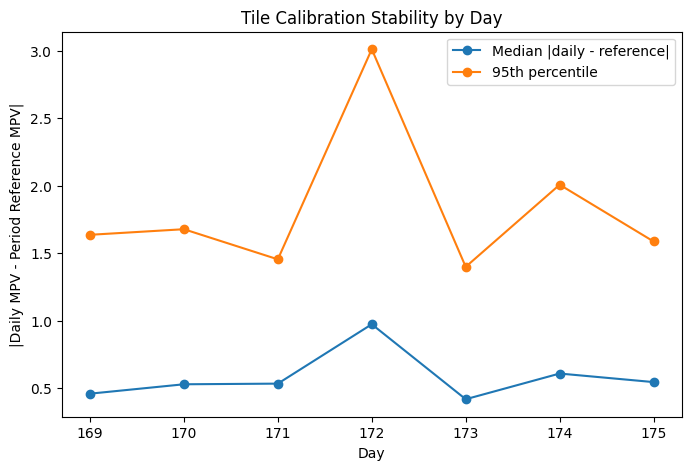

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    day_summary["day"],
    day_summary["median_abs_delta"],
    marker="o",
    label="Median |daily - reference|"
)

plt.plot(
    day_summary["day"],
    day_summary["p95_abs_delta"],
    marker="o",
    label="95th percentile"
)

plt.xlabel("Day")
plt.ylabel("|Daily MPV - Period Reference MPV|")
plt.title("Tile Calibration Stability by Day")
plt.legend()
plt.show()

In [25]:
# ============================================================
# EDA #5 — Diagnose Day 172
#
# Question:
# Is the larger Day-172 deviation a broad detector-wide shift,
# or is it concentrated in particular detector regions?
# ============================================================

day172 = cracz_eval[
    cracz_eval["day"] == 172
].copy()


# ------------------------------------------------------------
# First split by East/West.
#
# groupby("ew"):
#   collect rows with the same EW value,
#   then calculate summary statistics for each group.
# ------------------------------------------------------------

ew_summary = (
    day172.groupby("ew")
    .agg(
        n_tiles=("abs_delta_mpv", "size"),
        median_abs_delta=("abs_delta_mpv", "median"),
        p95_abs_delta=(
            "abs_delta_mpv",
            lambda x: x.quantile(0.95)
        ),
        max_abs_delta=("abs_delta_mpv", "max"),
    )
    .reset_index()
)

display(ew_summary)


# ------------------------------------------------------------
# Then split by EW + PP.
#
# This lets us locate whether particular detector positions
# contribute disproportionately to the Day-172 deviation.
# ------------------------------------------------------------

pp_summary = (
    day172.groupby(["ew", "pp"])
    .agg(
        n_tiles=("abs_delta_mpv", "size"),
        median_abs_delta=("abs_delta_mpv", "median"),
        p95_abs_delta=(
            "abs_delta_mpv",
            lambda x: x.quantile(0.95)
        ),
        max_abs_delta=("abs_delta_mpv", "max"),
    )
    .reset_index()
    .sort_values(
        "median_abs_delta",
        ascending=False
    )
)

display(pp_summary)

,ew,n_tiles,median_abs_delta,p95_abs_delta,max_abs_delta
0,0,372,0.891834,2.869857,4.784412
1,1,372,1.056445,3.157206,5.106853


,ew,pp,n_tiles,median_abs_delta,p95_abs_delta,max_abs_delta
23,1,12,31,1.610338,4.253032,4.983010
14,1,3,31,1.351277,3.203463,3.892494
21,1,10,31,1.349411,2.925945,3.362393
5,0,6,31,1.324018,2.970789,3.380004
20,1,9,31,1.245611,3.037685,4.429268
9,0,10,31,1.155004,2.216106,2.751530
16,1,5,31,1.138869,2.849138,3.530709
11,0,12,31,1.039076,2.545749,4.293920
18,1,7,31,0.969868,2.970975,3.143903
15,1,4,31,0.961457,2.535962,3.134091


In [26]:
# ============================================================
# EDA #6 — Signed day-level shift
#
# abs_delta_mpv tells us HOW FAR a daily value is from
# the period reference.
#
# delta_mpv tells us WHICH DIRECTION:
#
#   delta_mpv > 0
#       daily MPV is above the period reference
#
#   delta_mpv < 0
#       daily MPV is below the period reference
#
# If Day 172 has a large median signed delta,
# that suggests a coherent day-level shift.
#
# If median signed delta is near zero but |delta| is large,
# that suggests tile-to-tile scatter instead.
# ============================================================

signed_day_summary = (
    cracz_eval.groupby("day")
    .agg(
        # Typical signed shift
        median_delta=("delta_mpv", "median"),

        # Mean signed shift
        mean_delta=("delta_mpv", "mean"),

        # Typical magnitude, independent of sign
        median_abs_delta=("abs_delta_mpv", "median"),

        # Fraction of tiles above the period reference
        fraction_positive=(
            "delta_mpv",
            lambda x: (x > 0).mean()
        ),
    )
    .reset_index()
)

display(signed_day_summary)

,day,median_delta,mean_delta,median_abs_delta,fraction_positive
0,169,-0.057121,0.007290,0.458649,0.455645
1,170,-0.311549,-0.326208,0.528270,0.331989
2,171,-0.100681,-0.119595,0.533087,0.446237
3,172,-0.527007,-0.501182,0.972973,0.330645
4,173,0.214067,0.256880,0.417572,0.657258
5,174,-0.100043,-0.143775,0.607871,0.452957
6,175,-0.032319,-0.041558,0.544467,0.483871


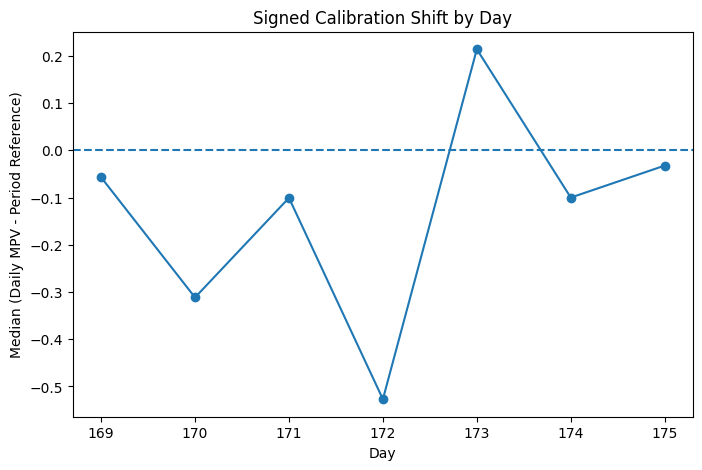

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    signed_day_summary["day"],
    signed_day_summary["median_delta"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Day")
plt.ylabel("Median (Daily MPV - Period Reference)")
plt.title("Signed Calibration Shift by Day")
plt.show()

In [28]:
# ============================================================
# EDA #7 — Separate day-level shift from tile-level variation
#
# Model:
#
#   daily deviation
#       =
#   day-level common shift
#       +
#   tile-level residual
#
# We estimate the common shift using the MEDIAN delta of
# all 744 tiles on that day.
#
# Why median?
# It is robust against a small number of unusual tiles.
# ============================================================


# ------------------------------------------------------------
# transform("median")
#
# groupby("day") groups rows by day.
#
# transform("median") then calculates the median delta for
# each day AND broadcasts that value back to every row.
#
# Example:
#
# day    delta       day_median_delta
# 169    -0.3            -0.05
# 169    +0.2            -0.05
# 169    -0.1            -0.05
#
# Unlike agg(), transform() keeps the original number of rows.
# ------------------------------------------------------------

cracz_eval["day_median_delta"] = (
    cracz_eval
    .groupby("day")["delta_mpv"]
    .transform("median")
)


# Remove the common day-level shift.
#
# residual > 0:
#     this tile is above the typical behavior for that day
#
# residual < 0:
#     this tile is below the typical behavior for that day
cracz_eval["residual_delta"] = (
    cracz_eval["delta_mpv"]
    - cracz_eval["day_median_delta"]
)

cracz_eval["abs_residual_delta"] = (
    cracz_eval["residual_delta"].abs()
)


# ------------------------------------------------------------
# Compare residual spread across days.
# ------------------------------------------------------------

residual_summary = (
    cracz_eval.groupby("day")
    .agg(
        day_shift=(
            "day_median_delta",
            "first"
        ),

        median_abs_residual=(
            "abs_residual_delta",
            "median"
        ),

        p95_abs_residual=(
            "abs_residual_delta",
            lambda x: x.quantile(0.95)
        ),
    )
    .reset_index()
)

display(residual_summary)

,day,day_shift,median_abs_residual,p95_abs_residual
0,169,-0.057121,0.458678,1.689569
1,170,-0.311549,0.475865,1.561107
2,171,-0.100681,0.535680,1.417517
3,172,-0.527007,0.889954,3.071300
4,173,0.214067,0.373973,1.256173
5,174,-0.100043,0.612892,1.971455
6,175,-0.032319,0.545445,1.566462


## Expert Calibration Workflow and Baseline Contract

Daily MPV values are intermediate measurements, not the final calibration constants.

The final calibration is obtained by evaluating the same detector tile across a multi-day period and performing a constant fit to derive a stable reference value.

Expert review may be triggered when:

- the fitted spectrum or fit quality appears suspicious;
- the calibration candidate deviates substantially from its expected value, roughly on the order of 10 ADC based on current expert practice;
- cross-day behavior is inconsistent;
- detector or run conditions require interpretation.

Expert review may also incorporate external operational context, including:

- beam conditions;
- detector configuration changes;
- magnetic-field or experimental setup changes;
- run and shift logs.

Possible expert outcomes include:

- Accept;
- Refit;
- Exclude or mark as bad;
- Accept with an explained run-condition effect.

### ML implication

Numerical deviation alone is not the ground-truth label.

Calibration reliability depends on both quantitative evidence and expert operational context.

The ML system should therefore aim to automate routine cases while routing ambiguous or unusual cases to expert review.

## Classical ML Baseline — Predict Period Reference MPV

Goal:

Given a tile-day's intermediate daily fit result, predict the final multi-day reference calibration value.

This is a secondary task, not the final reliability-classification objective.

Why start here:

- the target is well-defined;
- the existing daily MPV provides a strong deterministic baseline;
- we can test whether a simple ML model improves over directly using the daily MPV;
- this gives us a complete train → predict → evaluate ML pipeline without inventing weak labels.

In [29]:
# ============================================================
# Classical ML baseline
#
# Task:
#   daily measurement --> period reference MPV
#
# IMPORTANT:
# We intentionally start with only:
#
#   mpv
#   mpv_error
#
# We do NOT initially use:
#
#   ew, pp, tt
#
# because the same physical tiles appear repeatedly across days.
# Including tile identity immediately could let the model
# memorize tile-specific calibration values instead of learning
# how daily measurements relate to the period reference.
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


features = ["mpv", "mpv_error"]

# Temporal split:
#
# Train on earlier days.
# Test on later days.
#
# This is better than a random split because calibration data
# naturally arrive over time.
train = cracz_eval[
    cracz_eval["day"] <= 173
].copy()

test = cracz_eval[
    cracz_eval["day"] >= 174
].copy()

X_train = train[features]
y_train = train["reference_mpv"]

X_test = test[features]
y_test = test["reference_mpv"]

print("Train rows:", len(train))
print("Test rows:", len(test))

Train rows: 3720
Test rows: 1488


## Modeling Notes and Follow-up Questions

### Task A — Daily Measurement → Period Calibration Reference

Current proof-of-concept task:

- Input: daily fitted MPV and fitting uncertainty.
- Target: multi-day period calibration reference obtained from the constant fit.
- Baseline 0: use the daily MPV directly.
- Baseline 1: use a simple classical ML model such as Linear Regression.
- Evaluation: compare MAE / RMSE on later days.

Important limitation:

The Days 169–175 period reference was itself computed using all seven days. Therefore, using Days 169–173 for training and Days 174–175 for testing does not provide a fully independent test target.

This is acceptable for an initial proof of concept, but a production-quality evaluation should train on one calibration period and evaluate on a separate period to avoid temporal / target leakage.

### Task B — Raw ADC Spectrum → Daily MPV

A second ML problem is to replace or augment the existing multi-MIP Landau-convolution fitting step.

Traditional approach:

ADC histogram → 1/2/3-MIP Landau-convolution fit → daily MPV

Possible ML approach:

4096-bin ADC histogram → ML / 1D CNN → predicted daily MPV

Useful comparisons include:

- MPV accuracy against expert-accepted or manually refitted values;
- robustness to low statistics, spikes, and unusual spectrum shapes;
- numerical failure rate;
- inference speed versus iterative nonlinear fitting.

Important label caveat:

If the ML model is trained only on MPVs produced by the existing Landau fit, then the model is primarily learning to imitate the existing algorithm. It may be faster or more robust, but this alone does not prove that it is more accurate.

A stronger evaluation would compare both the traditional fit and the ML prediction against expert-reviewed / accepted calibration values or independent downstream calibration quality.

In [30]:
# ============================================================
# Baseline 0 — Existing daily MPV
#
# Simplest estimator:
#
#   predicted period reference = daily fitted MPV
#
# Before using ML, we need to know how strong the existing
# physics-based result already is.
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_pred = test["mpv"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = mean_squared_error(
    y_test,
    baseline_pred
) ** 0.5

print("Daily-MPV baseline")
print(f"MAE : {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")

Daily-MPV baseline
MAE : 0.7094
RMSE: 0.9368


In [31]:
# ============================================================
# Baseline 1 — Linear Regression
#
# Inputs:
#   daily MPV
#   daily MPV fitting uncertainty
#
# The model learns:
#
# reference_mpv
#     ≈ w1 * mpv
#     + w2 * mpv_error
#     + bias
# ============================================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

ml_pred = model.predict(X_test)

ml_mae = mean_absolute_error(
    y_test,
    ml_pred
)

ml_rmse = mean_squared_error(
    y_test,
    ml_pred
) ** 0.5

print("Linear Regression")
print(f"MAE : {ml_mae:.4f}")
print(f"RMSE: {ml_rmse:.4f}")

print("\nCoefficients:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.6f}")

print(f"Intercept: {model.intercept_:.6f}")

Linear Regression
MAE : 0.6771
RMSE: 0.9143

Coefficients:
mpv: 0.949026
mpv_error: 0.393309
Intercept: 6.787873


In [32]:
print("\n=== Comparison ===")
print(f"Daily MPV baseline MAE : {baseline_mae:.4f}")
print(f"Linear Regression MAE  : {ml_mae:.4f}")

print(f"Daily MPV baseline RMSE: {baseline_rmse:.4f}")
print(f"Linear Regression RMSE : {ml_rmse:.4f}")


=== Comparison ===
Daily MPV baseline MAE : 0.7094
Linear Regression MAE  : 0.6771
Daily MPV baseline RMSE: 0.9368
Linear Regression RMSE : 0.9143


### Reference Uncertainty Note

The period reference MPV is itself obtained from a multi-day constant fit, so it also has an associated fitting uncertainty.

The current proof-of-concept regression treats the reference MPV as a point target for simplicity.

A more rigorous evaluation could later incorporate the reference uncertainty through weighted fitting, uncertainty-aware metrics, or confidence-interval comparisons.

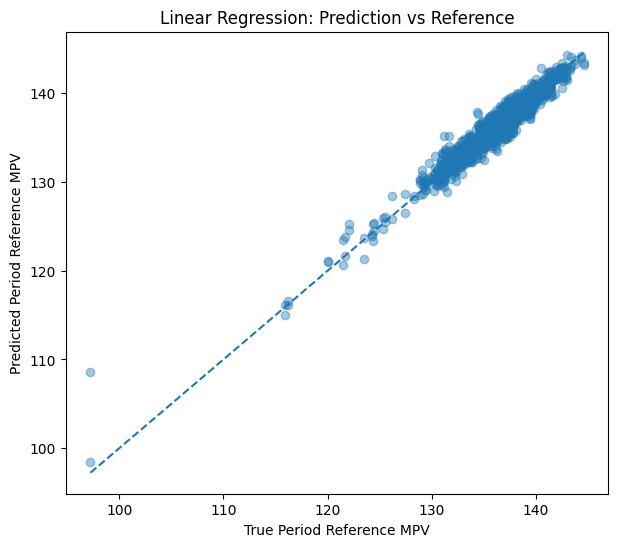

In [33]:
# ============================================================
# Visualize regression performance
#
# x-axis:
#   true period reference MPV
#
# y-axis:
#   model-predicted period reference MPV
#
# Perfect predictions would lie on:
#
#   y = x
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    ml_pred,
    alpha=0.4
)

min_val = min(y_test.min(), ml_pred.min())
max_val = max(y_test.max(), ml_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("True Period Reference MPV")
plt.ylabel("Predicted Period Reference MPV")
plt.title("Linear Regression: Prediction vs Reference")

plt.show()

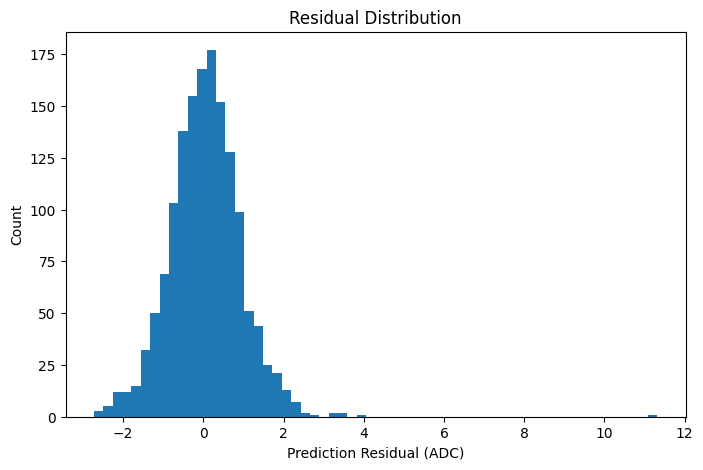

Median residual: 0.058618276320231644
Mean residual: 0.06023615494123354


In [34]:
# ============================================================
# Residual
#
# residual = prediction - true value
#
# residual > 0:
#   model over-predicts
#
# residual < 0:
#   model under-predicts
# ============================================================

residual = ml_pred - y_test

plt.figure(figsize=(8, 5))

plt.hist(
    residual,
    bins=60
)

plt.xlabel("Prediction Residual (ADC)")
plt.ylabel("Count")
plt.title("Residual Distribution")

plt.show()

print("Median residual:", residual.median())
print("Mean residual:", residual.mean())

In [35]:
# ============================================================
# EDA / Evaluation — Inspect worst regression failures
#
# Good average metrics can hide rare but important failures.
#
# residual:
#
#   prediction - true reference
#
# abs_residual:
#
#   size of the error regardless of direction
# ============================================================

test_results = test.copy()

test_results["prediction"] = ml_pred

test_results["residual"] = (
    test_results["prediction"]
    - test_results["reference_mpv"]
)

test_results["abs_residual"] = (
    test_results["residual"].abs()
)


# ------------------------------------------------------------
# Sort from largest prediction error to smallest.
#
# ascending=False:
#     largest abs_residual appears first.
# ------------------------------------------------------------

worst = (
    test_results
    .sort_values(
        "abs_residual",
        ascending=False
    )
    [
        [
            "day",
            "ew",
            "pp",
            "tt",
            "mpv",
            "mpv_error",
            "reference_mpv",
            "prediction",
            "residual",
            "abs_residual"
        ]
    ]
    .head(15)
)

display(worst)

,day,ew,pp,tt,mpv,mpv_error,reference_mpv,prediction,residual,abs_residual
4247,174,1,6,1,105.707642,3.665784,97.228460,108.548919,11.320459,11.320459
4312,174,1,8,4,134.916473,0.919235,131.163485,135.188605,4.025120,4.025120
4186,174,1,4,2,134.777237,1.354914,131.691231,135.227823,3.536592,3.536592
4960,175,1,5,1,137.640152,1.107976,134.350196,137.847679,3.497483,3.497483
4838,175,1,1,3,137.553558,0.977927,134.481045,137.714350,3.233305,3.233305
4470,175,0,1,7,124.187141,1.517919,122.101379,125.241662,3.140283,3.140283
4166,174,1,3,13,133.114227,1.114506,136.284546,133.555029,-2.729517,2.729517
4433,174,1,12,1,132.354706,1.409627,130.291271,132.950298,2.659027,2.659027
5179,175,1,12,3,128.214615,0.926555,131.419985,128.831249,-2.588736,2.588736
4354,174,1,9,15,132.032410,1.121100,135.064376,132.530950,-2.533426,2.533426


In [36]:
# ============================================================
# Slice evaluation — known noisy detector tile
#
# Cameron's expert QA identified:
#
#   EW=1, PP=6, TT=1
#
# as persistently NOISY.
#
# We do NOT automatically delete this tile.
# Instead, evaluate it as a separate operational slice.
# ============================================================

test_results["known_noisy_tile"] = (
    (test_results["ew"] == 1)
    & (test_results["pp"] == 6)
    & (test_results["tt"] == 1)
)

normal_slice = test_results[
    ~test_results["known_noisy_tile"]
]

noisy_slice = test_results[
    test_results["known_noisy_tile"]
]

print("Normal test rows:", len(normal_slice))
print("Known noisy rows:", len(noisy_slice))

print("\nNormal slice:")
print(
    "MAE:",
    mean_absolute_error(
        normal_slice["reference_mpv"],
        normal_slice["prediction"]
    )
)

print("\nKnown noisy slice:")
print(
    noisy_slice[
        [
            "day", "ew", "pp", "tt",
            "mpv",
            "reference_mpv",
            "prediction",
            "abs_residual"
        ]
    ]
)

Normal test rows: 1486
Known noisy rows: 2

Normal slice:
MAE: 0.669499074476277

Known noisy slice:
      day  ew  pp  tt         mpv  reference_mpv  prediction  abs_residual
4247  174   1   6   1  105.707642       97.22846  108.548919     11.320459
4991  175   1   6   1   94.997208       97.22846   98.486750      1.258290


### Classical ML Baseline — Key Findings

- The existing daily MPV is already a strong baseline:
  - MAE = 0.709 ADC
  - RMSE = 0.937 ADC

- A simple Linear Regression using daily MPV and MPV uncertainty slightly improves performance:
  - MAE = 0.677 ADC
  - RMSE = 0.914 ADC

- The improvement is modest, suggesting that the physics-based daily fit already contains most of the useful signal.

- Average performance is nearly unbiased, with mean and median residuals close to zero.

- The largest regression error occurs on a detector tile that experts had identified as persistently noisy.

- The noisy tile does not fail consistently across days, so detector identity alone should not be treated as a deterministic failure label.

- Aggregate metrics must therefore be complemented by slice-level evaluation and detector/run-condition context.

- A more complex model should only be justified if it improves robustness on meaningful failure slices, not merely average MAE.

## Evaluation for a Human-in-the-Loop Calibration System

Define the positive class as:

> `needs_review = 1`

A positive prediction means the system routes the calibration to an expert.

The important error types are:

- False Positive: routine calibration is unnecessarily sent to expert review.
- False Negative: problematic calibration is automatically accepted.

For this system, a false negative is more costly because an unreliable calibration may pass downstream.

Therefore, evaluation should prioritize high recall on cases that truly need expert review, while still reducing expert workload.

In [39]:
y_true = [1, 1, 1, 0, 0, 0, 0, 0]
y_pred = [1, 1, 0, 1, 0, 0, 0, 0]

tp = fp = tn = fn = 0

for true, pred in zip(y_true, y_pred):
    if true == 1 and pred == 1:
        tp += 1
    elif true == 1 and pred == 0:
        fn += 1
    elif true == 0 and pred == 1:
        fp += 1
    elif true == 0 and pred == 0:
        tn += 1


precision = tp / (tp + fp)
recall = tp / (tp + fn)
accuracy = (tp + tn) / (tp + tn + fp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)
print("F1:", f1)



Precision: 0.6666666666666666
Recall: 0.6666666666666666
Accuracy: 0.75
F1: 0.6666666666666666


In [40]:
# ==============================================================================
# NOTE:
# The scores below are synthetic examples for practicing
# threshold-based classification evaluation.
#
# In a real ML classifier, these scores would come from the model,
# e.g. predict_proba() or a sigmoid output.
# Threshold -> Prediction -> Evaluation
#
# Positive Class:
# 1 = needs expert Review
#
# Model Output:
#   score between 0 and 1
#
# Decision rule:
#
#   score >= threshold -> send to expert
#   score < threshold -> auto-accept
# ==============================================================================

y_true = [1, 1, 1, 0, 0, 0, 0, 0]

scores = [0.95, 0.80, 0.45, 0.70, 0.40, 0.30, 0.20, 0.10]

threshold = 0.5

# Convert continuous scores into binary decisions。
#
# Example:
# score = 0.80 > 0.5 -> 1
# score = 0.30 < 0.5 -> 0

y_pred = [
    1 if score >= threshold else 0
    for score in scores
]

print("y_pred: ", y_pred)

y_pred:  [1, 1, 0, 1, 0, 0, 0, 0]


In [42]:
def evaluate(y_true, y_pred):
  tp = fp = tn = fn = 0

  for true, pred in zip(y_true, y_pred):
    if true == 1 and pred == 1:
      tp += 1
    elif true == 1 and pred == 0:
      fn += 1
    elif true == 0 and pred == 1:
      fp += 1
    elif true == 0 and pred == 0:
      tn += 1

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0
  recall = tp / (tp + fn) if (tp + fn) > 0 else 0
  accuracy = (tp + tn) / len(y_true)

  f1 = (
      2 * precision * recall / (precision + recall)
      if (precision + recall) > 0
      else 0
  )

  return precision, recall, accuracy, f1

In [43]:
thresholds = [0.3, 0.5, 0.7, 0.9]

for threshold in thresholds:
  y_pred = [
      1 if score >= threshold else 0
      for score in scores
  ]

  precision, recall, accuracy, f1 = evaluate(
      y_true,
      y_pred
  )

  print(
      threshold,
      precision,
      recall,
      accuracy,
      f1
  )

0.3 0.5 1.0 0.625 0.6666666666666666
0.5 0.6666666666666666 0.6666666666666666 0.75 0.6666666666666666
0.7 0.6666666666666666 0.6666666666666666 0.75 0.6666666666666666
0.9 1.0 0.3333333333333333 0.75 0.5
